<a href="https://colab.research.google.com/github/LuanLindolfo/machinelearning/blob/Aprendizagemporreforco/Aprendizagem_por_reforco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizagem por Reforço com Q-Learning

- Código adaptado de: https://www.learndatasci.com/tutorials/reinforcement-q-learning-scratch-python-openai-gym/

In [ ]:
!pip uninstall gym

In [ ]:
!pip install gym==0.17.3
# Use esta versão para conseguir visualizar o ambiente

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.2 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.17.3-py3-none-any.whl size=1654617 sha256=30fac8577acbb6d65ddf5144d78ce962b070c35f09845c50f46ca83a0e7c8ab3
  Stored in directory: /root/.cache/pip/wheels/07/8b/b7/570cb90b10f17e85ccb291ba1f04af41ec697745104a2263eb
Successfully built gym
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.1
    Uninstalling cloudpickle-3.1.1:
      Successfully uninstalled cloudpickle-3.1.1
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2024.12.1 requires cloud

## Entendimento do ambiente

In [ ]:
#algoritmo genérico que pode ser utilizado em outros ambientes (do gym desse framework) de aprendizagem por reforço


import gym #gym é o framework que já possui os ambientes prontos
import random
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"
gym.__version__

'0.17.3'

In [ ]:
env = gym.make('Taxi-v3') #env de envelopment
#documentação  do ambiente - gym.openai

In [ ]:
env.reset()
#reset() - resetando a posição do taxi, do ponto de embarque e do ponto de desembarque

493

In [ ]:
env.render()
#.render() -> mostrando o ambiente
#taxi amarelo - não pegou opassageira
#taxi verde - pegou o passageiro

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [ ]:
env.reset()
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [ ]:
# 0 = south 1 = north 2 = east 3 = west 4 = pickup 5 = dropoff
print(env.action_space)
#.action_space - espaço de ações que o agente pode fazer
#cima, baixo, direita, esquerda, pegar o passageiro e deixar o passageiro

Discrete(6)


In [ ]:
#5*5*5*4 -- Atualizado 22/11/2022 ref. https://www.gymlibrary.dev/environments/toy_text/taxi/#observations
25*5*4 #quantidade total de estados nesse ambiente

500

In [ ]:
# 4 destinos
print(env.observation_space)
#.observation_space - observando as ações disponíveis
#500 movimentos - espaço de busca, espaço de estado

Discrete(500)


In [ ]:
len(env.P)#visualizando os estado
#.P variaveis que armazena os estados possíveis

500

In [ ]:
env.P[484]#selecionando uma das ações
#elementos nessa matriz são
#1 - probabilidade
#2 - próximo estado
#3 - recompensa que vai ganhar
#4 - indica se o episódio, ou o jogo, terminou

{0: [(1.0, 484, -1, False)],
 1: [(1.0, 384, -1, False)],
 2: [(1.0, 484, -1, False)],
 3: [(1.0, 464, -1, False)],
 4: [(1.0, 484, -10, False)],
 5: [(1.0, 484, -10, False)]}

## Treinamento

Diferença temporal (Q-learning)

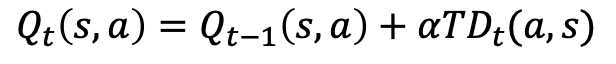

TD -> recompensa * gama + valor do proximo estado

In [ ]:
random.uniform(0, 1)#sempre que executar gera um número entre 0 e 1

0.9451013568460971

In [ ]:
env.action_space

Discrete(6)

In [ ]:
import numpy as np
q_table = np.zeros([env.observation_space.n, env.action_space.n])
q_table.shape
#inicializou uma tabela com 500 linhas que indica cada um dos movimentos e 6 colunas que indica cada uma das ações
#todas aquelas de norte, sul, direita, esquerda, pegar e deixar o passageiro

(500, 6)

In [ ]:
q_table #tabela que vai ter todos os valores da qualidade de cada ação

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [ ]:
np.argmax(np.array([3, 5]))

np.int64(1)

In [ ]:
#basicamente o treinamento do algoritmo é encontrar a tabela de movimentações e ações conforme o valor randomico
#nessa parte ele explora todo o ambiente com 100mil episódios para poder verificar o melhor caminho

# 1-10% 3-90%
# exploration / exploitation
# 0 = south 1 = north 2 = east 3 = west 4 = pickup 5 = dropoff
%%time
#pra saber o tempo que vai levar
from IPython.display import clear_output

alpha = 0.1
gamma = 0.6
epsilon = 0.1#probabilidade randomica que vou levar pra explorar o ambiente


#executando o for 100000 vezes
#cada execução é um episódio
for i in range(100000):
  #estado - atual
  estado = env.reset() #inicializado aleatoriamente

  penalidades, recompensa = 0, 0
  done = False #controla se terminou a execução ou não
  while not done:
    #se vai usar exploração ou exploitation
    # Exploração
    if random.uniform(0, 1) < epsilon:
      acao = env.action_space.sample()
      #env.action_space - vai retornar o valor que indica as movimentações
      #.sample() - escolhe uma ação randomica
    # Exploitation - ideia é usar o maior valor da tabela
    else:
      acao = np.argmax(q_table[estado])#tem que passar o estado da linha e a coluna da ação

    #aqui busca a recompensa diretamente com o ambiente
    proximo_estado, recompensa, done, info = env.step(acao)

    #proximo estado
    q_antigo = q_table[estado, acao]
    #pois tem que achar o maximo valor -> para o proximo estado
    proximo_maximo = np.max(q_table[proximo_estado])

    q_novo = (1 - alpha) * q_antigo + alpha * (recompensa + gamma * proximo_maximo)
    #atualização do valor de Q
    q_table[estado, acao] = q_novo

    #contando as penalidades que o algoritmo vai gerar
    #objetivo é reduzir as penalidades
    if recompensa == -10:
      penalidades += 1

    estado = proximo_estado

  if i % 100 == 0:
    clear_output(wait=True)
    print('Episódio: ', i)

print('Treinamento concluído')

Episódio:  99900
Treinamento concluído
CPU times: user 46.9 s, sys: 8.36 s, total: 55.2 s
Wall time: 51.9 s


In [ ]:
#dada a tabela qtable, é possível executar o ambiente para que ele não tenha praticamente nenhum erro

# 0 = south 1 = north 2 = east 3 = west 4 = pickup 5 = dropoff
q_table[346]
#valores atualizados na qtable por meio da fórmula

#aqui, com base no estado (informado embaixo), abre o estado e vê o maior valor
#aqui nesse exemplo, a posição 1 -> east, é a melhor opção

array([ -2.49350418,  -2.48236806,  -2.48937753,  -2.49361829,
       -11.48099391, -11.4399292 ])

In [ ]:
env.reset()
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [ ]:
env.step(1)#tomou o maior valor do estado, no caso na posição 1
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)


In [ ]:
env.step(1)#tomou o maior valor do estado, no caso na posição 1
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)


In [ ]:
env.encode(3, 2, 1, 2) #indica o estado conforme os parâmetros de localização
#passando como parametro a linha do taxi, coluna do taxi, localização do passageiro e o destino do passageiro
#vendo na tabela, o estado, verifica o maior valor para a tomada de ação
#sobre a localização do passageiro e o destino do passageiro
#r - 0, g - 1, b - 2 e y - 3

346

## Avaliação

In [ ]:
total_penalidades = 0
episodios = 50
frames = []

for _ in range(episodios): #_ pois não vamos utilizar a variável que vai rodar o for
  estado = env.reset() #estado inicial randomico
  penalidades, recompensa = 0, 0
  done = False #quando termina a execução
  while not done:
    acao = np.argmax(q_table[estado]) #consultando a tabela do estado pra ver qual o maior valor (como feito acima) e tomar a melhor ação
    #np.argmax - verifica o maior valor
    estado, recompensa, done, info = env.step(acao)
    #novo estado, atualiza o valor de recompensa, verifica o done, e atualiza informação
    #env.step(acao) - toma a maior ação dentro do estado

    if recompensa == -10:
      #quando leva o passageiro para o lugar errado, incrementa o numero de penalidades
      penalidades += 1

    frames.append({
        #armazenando os estado neste dicionário
        'frame': env.render(mode='ansi'),#frame atual - formato de visualização
        'state': estado,#estado atual
        'action': acao,#ação
        'reward': recompensa#recompensa
    })

  total_penalidades += penalidades#armazena o total de penalidades

#printa o numero de episódios e penalidades
#quantas vezes levou o passageiro para o lugar errado
print('Episódios', episodios)
print('Penalidades', total_penalidades)

Episódios 50
Penalidades 0


In [ ]:
frames[0] #imprimir o dicionário
#desenho da estrutura

{'frame': '+---------+\n|R: | : :G|\n| : | : : |\n| : : : : |\n| | : | : |\n|\x1bY\x1b| : |\x1bB\x1b:\x1b \x1b|\n+---------+\n  (South)\n',
 'state': 494,
 'action': np.int64(0),
 'reward': -1}

In [ ]:
#colocando em um dicionários as informações (principalmente o frame em formato de visualização)
#imprimindo no formato padrão do desenho
#percorrendo cada informação do dicionário com um delay
#printando, e atualizando, cada estado, ação e recompensa e penalidade que irá tomar
from time import sleep
for frame in frames:
  #percorrendo cada elemento do dicionário
  clear_output(wait=True)
  #wait=True - pra dar um delay
  #acionando as posições
  print(frame['frame'])
  print('Estado', frame['state'])
  print('Ação', frame['action'])
  print('Recompensa', frame['reward'])
  sleep(.5)#tempo de delay

  #começa um novo estado (em um ambiente totalmente aleatório que tá iniciando
  #cada um dos episódios (treinados na exploração de ambiente - na tabela))

  #não precisa de dados, apenas o dado da espécie de treinamento (exploração e exploitation)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Estado 309
Ação 0
Recompensa -1


KeyboardInterrupt: 